# Cross-Run Comparison: CLEANSER vs Sceptre

Direct side-by-side comparison of QC and inference metrics across pipeline runs.

**Key questions:**
- How does guide assignment differ between CLEANSER and Sceptre?
- Are direct target knockdown results concordant?
- Where do the two pipelines diverge most?

In [36]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [37]:
# Config
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
RESULTS_DIR = BASE_DIR / "results" / "cross_tech_comparison"
OUTPUT_DIR = RESULTS_DIR / "cross_run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Runs to compare — extend this list as new runs are added
RUNS = {
    "cleanser_unified": {"label": "CLEANSER", "color": "#1f77b4"},
    "sceptre_v11":      {"label": "Sceptre",  "color": "#ff7f0e"},
}

# Colors and ordering
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors
dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

SUFFIX = '_WTC11-benchmark_TF-Perturb-seq'
def short_name(ds):
    return ds.replace(SUFFIX, '').replace('_', ' ')

short_names = [short_name(ds) for ds in dataset_order]
color_by_short = {short_name(ds): dataset_colors[ds] for ds in dataset_order}

run_labels = list(RUNS.keys())
run_display = {k: v['label'] for k, v in RUNS.items()}
run_colors = {k: v['color'] for k, v in RUNS.items()}

print(f"Comparing: {[v['label'] for v in RUNS.values()]}")
print(f"Datasets: {short_names}")
print(f"Output: {OUTPUT_DIR}")

Comparing: ['CLEANSER', 'Sceptre']
Datasets: ['Hon', 'Huangfu', 'Gersbach GEM-Xv3', 'Gersbach HTv2', 'Engreitz']
Output: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cross_run


In [38]:
# Load metrics from all runs
guide_metrics = {}
gene_metrics = {}
target_metrics = {}
target_results = {}

for run in run_labels:
    run_dir = RESULTS_DIR / run
    
    # Guide metrics (per-dataset 'all' batch rows)
    f = run_dir / "combined_guide_metrics.tsv"
    if f.exists():
        df = pd.read_csv(f, sep="\t")
        df = df[df['batch'] == 'all'].copy()
        df['short_name'] = df['dataset'].apply(short_name)
        df['run'] = run
        guide_metrics[run] = df
        print(f"  Guide metrics [{run}]: {len(df)} datasets")
    
    # Gene metrics
    f = run_dir / "combined_gene_metrics.tsv"
    if f.exists():
        df = pd.read_csv(f, sep="\t")
        df = df[df['batch'] == 'all'].copy()
        df['short_name'] = df['dataset'].apply(short_name)
        df['run'] = run
        gene_metrics[run] = df
        print(f"  Gene metrics  [{run}]: {len(df)} datasets")
    
    # Intended target metrics
    f = run_dir / "combined_intended_target_metrics.tsv"
    if f.exists():
        df = pd.read_csv(f, sep="\t")
        df['short_name'] = df['dataset'].apply(short_name)
        df['run'] = run
        target_metrics[run] = df
        print(f"  Target metrics [{run}]: {len(df)} datasets")
    
    # Intended target per-guide results
    f = run_dir / "combined_intended_target_results.tsv"
    if f.exists():
        df = pd.read_csv(f, sep="\t")
        df['short_name'] = df['dataset'].apply(short_name)
        df['run'] = run
        target_results[run] = df
        print(f"  Target results [{run}]: {len(df)} guides")

# Combine into single DataFrames
all_guide = pd.concat(guide_metrics.values(), ignore_index=True)
all_gene = pd.concat(gene_metrics.values(), ignore_index=True)
all_target_metrics = pd.concat(target_metrics.values(), ignore_index=True)
all_target_results = pd.concat(target_results.values(), ignore_index=True)

print(f"\nLoaded {len(all_guide)} guide metric rows, {len(all_target_results)} target result rows")

  Guide metrics [cleanser_unified]: 5 datasets
  Gene metrics  [cleanser_unified]: 5 datasets
  Target metrics [cleanser_unified]: 5 datasets
  Target results [cleanser_unified]: 2080 guides
  Guide metrics [sceptre_v11]: 5 datasets
  Gene metrics  [sceptre_v11]: 5 datasets
  Target metrics [sceptre_v11]: 5 datasets
  Target results [sceptre_v11]: 2080 guides

Loaded 10 guide metric rows, 4160 target result rows

Loaded 10 guide metric rows, 4160 target result rows


---
## 1. Guide Assignment Comparison

Side-by-side comparison of guide assignment metrics with shared axes.

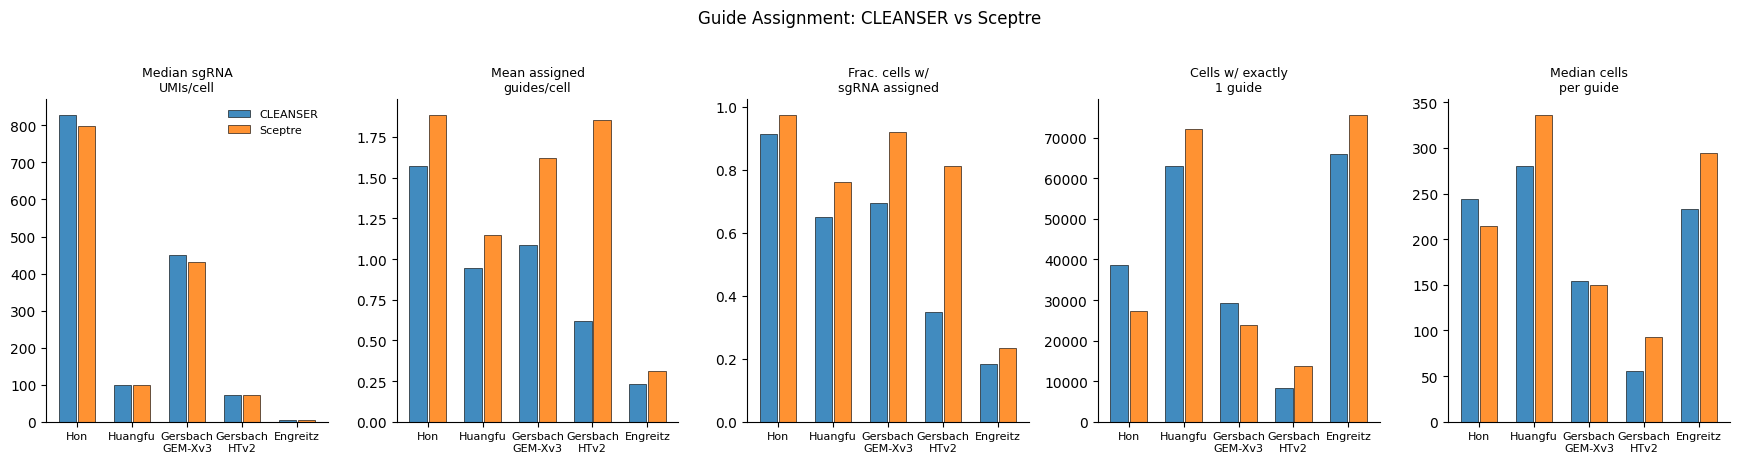

In [39]:
# Key guide metrics — grouped bar with shared y-axis per metric
metrics = [
    ('guide_umi_median',        'Median sgRNA\nUMIs/cell'),
    ('guides_per_cell_mean',    'Mean assigned\nguides/cell'),
    ('frac_cells_with_guide',   'Frac. cells w/\nsgRNA assigned'),
    ('n_cells_exactly_1_guide', 'Cells w/ exactly\n1 guide'),
    ('cells_per_guide_median',  'Median cells\nper guide'),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(3.5 * len(metrics), 4.5), sharey=False)

x = np.arange(len(short_names))
width = 0.35

for ax, (col, ylabel) in zip(axes, metrics):
    for j, run in enumerate(run_labels):
        df = all_guide[all_guide['run'] == run]
        vals = []
        for sn in short_names:
            row = df[df['short_name'] == sn]
            vals.append(row[col].values[0] if len(row) > 0 else 0)
        offset = (j - 0.5 * (len(run_labels) - 1)) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=run_display[run],
                      color=run_colors[run], edgecolor='black', linewidth=0.5, alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels([sn.replace(' ', '\n') for sn in short_names], fontsize=8)
    ax.set_title(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=8, frameon=False)
fig.suptitle('Guide Assignment: CLEANSER vs Sceptre', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'guide_assignment_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

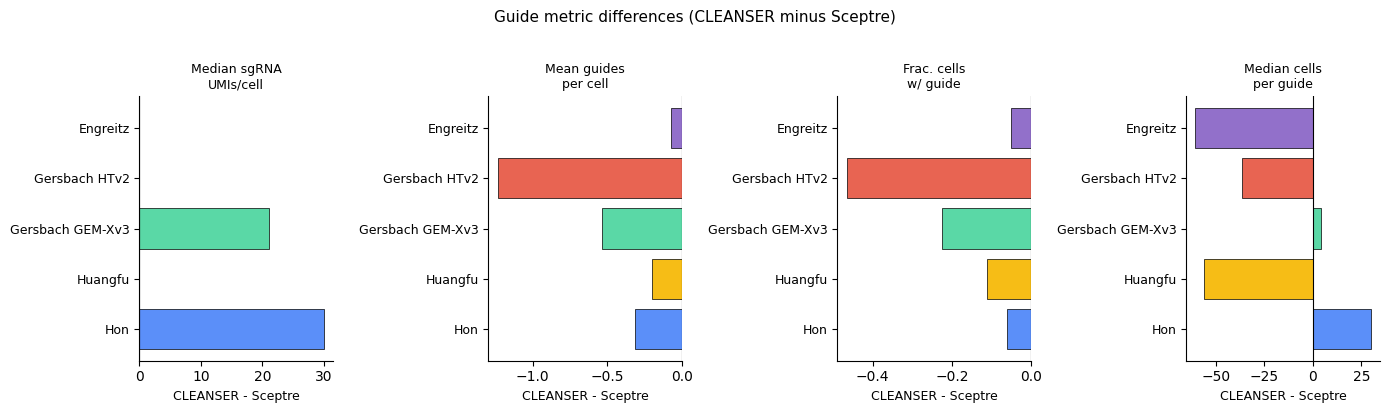

In [40]:
# Delta plot: CLEANSER minus Sceptre for key guide metrics
if len(run_labels) == 2:
    r1, r2 = run_labels
    d1 = all_guide[all_guide['run'] == r1].set_index('short_name')
    d2 = all_guide[all_guide['run'] == r2].set_index('short_name')
    common = d1.index.intersection(d2.index)
    
    delta_cols = ['guide_umi_median', 'guides_per_cell_mean', 'frac_cells_with_guide',
                  'cells_per_guide_median']
    delta_labels = ['Median sgRNA\nUMIs/cell', 'Mean guides\nper cell',
                    'Frac. cells\nw/ guide', 'Median cells\nper guide']
    
    fig, axes = plt.subplots(1, len(delta_cols), figsize=(3.5 * len(delta_cols), 4))
    
    for ax, col, label in zip(axes, delta_cols, delta_labels):
        deltas = d1.loc[common, col].values - d2.loc[common, col].values
        colors = [color_by_short[sn] for sn in common]
        ax.barh(range(len(common)), deltas, color=colors, edgecolor='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_yticks(range(len(common)))
        ax.set_yticklabels(common, fontsize=9)
        ax.set_xlabel(f'{run_display[r1]} - {run_display[r2]}', fontsize=9)
        ax.set_title(label, fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.suptitle(f'Guide metric differences ({run_display[r1]} minus {run_display[r2]})', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'guide_assignment_delta.pdf', dpi=300, bbox_inches='tight')
    plt.show()

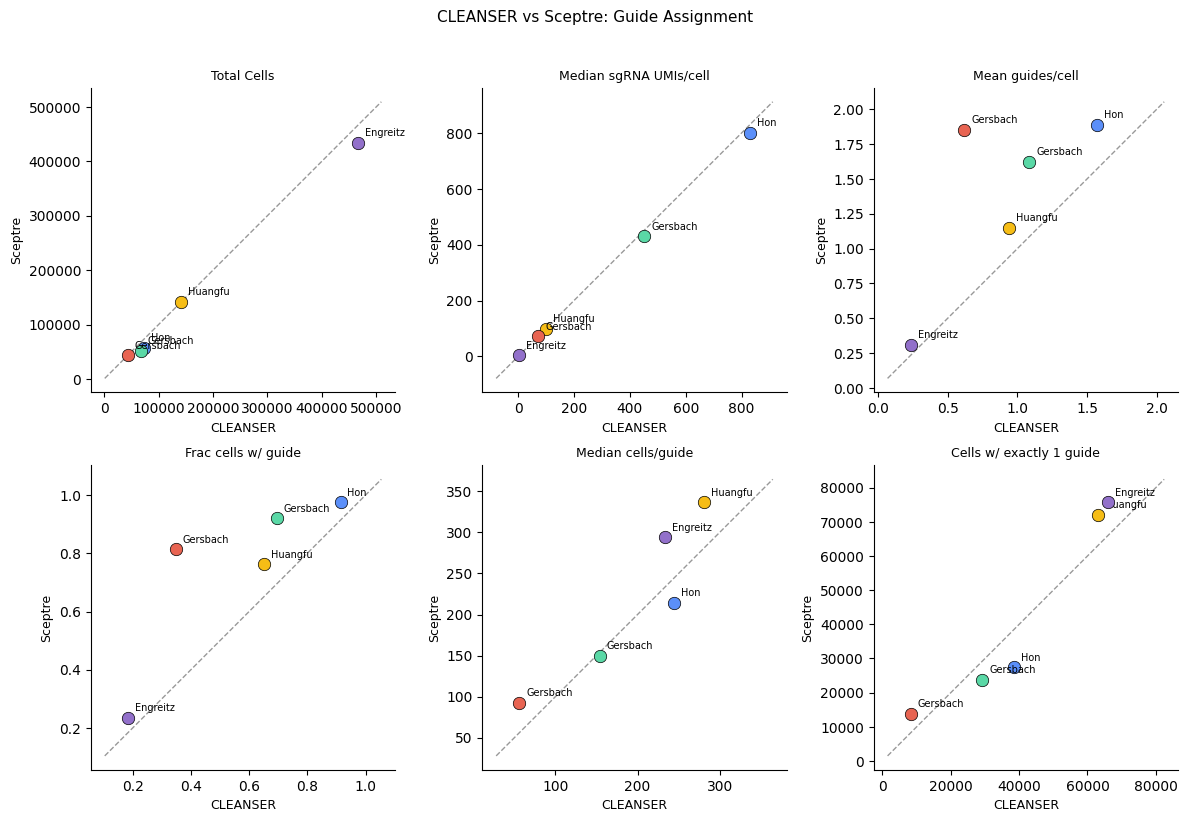

In [41]:
# Scatter: CLEANSER vs Sceptre per dataset — guide metrics + total cells (2x3)
if len(run_labels) == 2:
    r1, r2 = run_labels
    d1 = all_guide[all_guide['run'] == r1].set_index('short_name')
    d2 = all_guide[all_guide['run'] == r2].set_index('short_name')
    common = d1.index.intersection(d2.index)

    scatter_specs = [
        ('n_cells', 'Total Cells'),
        ('guide_umi_median', 'Median sgRNA UMIs/cell'),
        ('guides_per_cell_mean', 'Mean guides/cell'),
        ('frac_cells_with_guide', 'Frac cells w/ guide'),
        ('cells_per_guide_median', 'Median cells/guide'),
        ('n_cells_exactly_1_guide', 'Cells w/ exactly 1 guide'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for ax, (col, label) in zip(axes, scatter_specs):
        x_vals = d1.loc[common, col].values.astype(float)
        y_vals = d2.loc[common, col].values.astype(float)

        for i, sn in enumerate(common):
            ax.scatter(x_vals[i], y_vals[i], c=color_by_short[sn], s=80,
                       edgecolor='black', linewidth=0.5, zorder=3)
            ax.annotate(sn.split()[0], (x_vals[i], y_vals[i]),
                        textcoords='offset points', xytext=(5, 5), fontsize=7)

        # y = x diagonal
        all_vals = np.concatenate([x_vals, y_vals])
        lo, hi = all_vals.min(), all_vals.max()
        margin = (hi - lo) * 0.1 if hi > lo else 0.05
        ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
                'k--', alpha=0.4, linewidth=1)

        ax.set_xlabel(run_display[r1], fontsize=9)
        ax.set_ylabel(run_display[r2], fontsize=9)
        ax.set_title(label, fontsize=9)
        ax.set_aspect('equal')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(f'{run_display[r1]} vs {run_display[r2]}: Guide Assignment',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'guide_assignment_scatter.pdf', dpi=300, bbox_inches='tight')
    plt.show()

---
## 2. Direct Target Repression Comparison

How do intended target knockdown results compare between pipelines?

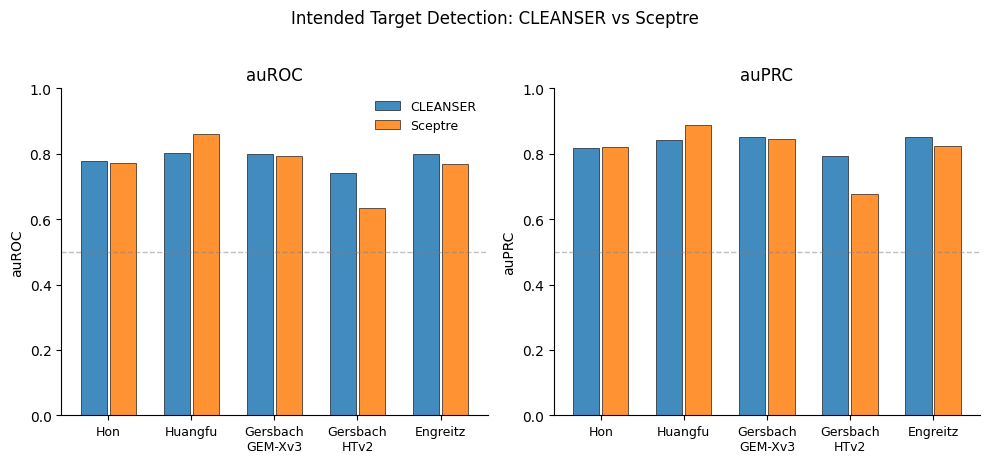

In [42]:
# auROC / auPRC side by side
metric_pairs = [('auroc', 'auROC'), ('auprc', 'auPRC')]

fig, axes = plt.subplots(1, len(metric_pairs), figsize=(5 * len(metric_pairs), 4.5))

for ax, (col, title) in zip(axes, metric_pairs):
    for j, run in enumerate(run_labels):
        df = all_target_metrics[all_target_metrics['run'] == run]
        vals = []
        for sn in short_names:
            row = df[df['short_name'] == sn]
            vals.append(row[col].values[0] if len(row) > 0 else np.nan)
        offset = (j - 0.5 * (len(run_labels) - 1)) * width
        ax.bar(x + offset, vals, width * 0.9, label=run_display[run],
               color=run_colors[run], edgecolor='black', linewidth=0.5, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([sn.replace(' ', '\n') for sn in short_names], fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=9, frameon=False)
fig.suptitle('Intended Target Detection: CLEANSER vs Sceptre', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_auroc_auprc_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

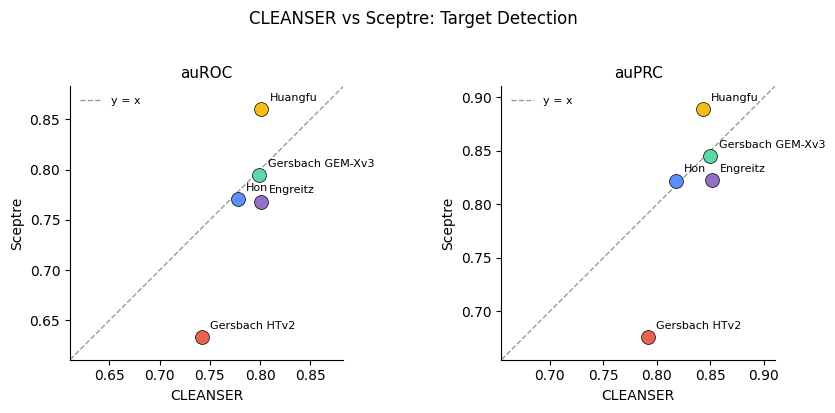

In [43]:
# Scatter: CLEANSER vs Sceptre for auROC and auPRC
if len(run_labels) == 2:
    r1, r2 = run_labels
    d1_t = all_target_metrics[all_target_metrics['run'] == r1].set_index('short_name')
    d2_t = all_target_metrics[all_target_metrics['run'] == r2].set_index('short_name')
    common = d1_t.index.intersection(d2_t.index)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    for ax, (col, title) in zip(axes, [('auroc', 'auROC'), ('auprc', 'auPRC')]):
        x_vals = d1_t.loc[common, col].values.astype(float)
        y_vals = d2_t.loc[common, col].values.astype(float)

        for i, sn in enumerate(common):
            ax.scatter(x_vals[i], y_vals[i], c=color_by_short[sn], s=100,
                       edgecolor='black', linewidth=0.5, zorder=3)
            ax.annotate(sn, (x_vals[i], y_vals[i]),
                        textcoords='offset points', xytext=(6, 6), fontsize=8)

        # y = x reference line
        all_vals = np.concatenate([x_vals, y_vals])
        lo, hi = all_vals.min(), all_vals.max()
        margin = (hi - lo) * 0.1 if hi > lo else 0.05
        ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
                'k--', alpha=0.4, linewidth=1, label='y = x')

        ax.set_xlim(lo - margin, hi + margin)
        ax.set_ylim(lo - margin, hi + margin)
        ax.set_xlabel(run_display[r1], fontsize=10)
        ax.set_ylabel(run_display[r2], fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.set_aspect('equal')
        ax.legend(fontsize=8, frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(f'{run_display[r1]} vs {run_display[r2]}: Target Detection',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'target_auroc_auprc_scatter.pdf', dpi=300, bbox_inches='tight')
    plt.show()

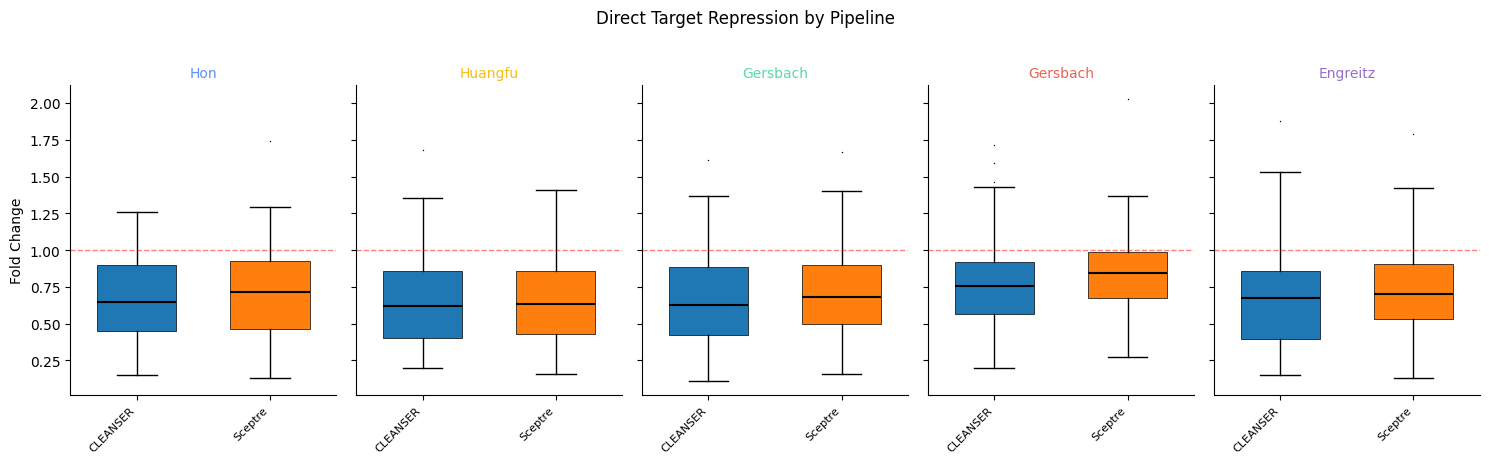

In [44]:
# Per-guide FC boxplot: side by side per dataset
# Filter to targeting + positive_control guides
plot_df = all_target_results.copy()
if 'label' in plot_df.columns:
    plot_df['label'] = plot_df['label'].replace({'positive control': 'positive_control'})
    plot_df = plot_df[plot_df['label'].isin(['positive_control', 'targeting'])]

plot_df['fc'] = 2 ** plot_df['log2_fc']

fig, axes = plt.subplots(1, len(short_names), figsize=(3 * len(short_names), 4.5),
                         sharey=True)

for ax, sn in zip(axes, short_names):
    subset = plot_df[plot_df['short_name'] == sn]
    data_list = []
    positions = []
    colors_list = []
    
    for j, run in enumerate(run_labels):
        run_data = subset[subset['run'] == run]['fc'].dropna()
        if len(run_data) > 0:
            data_list.append(run_data.values)
            positions.append(j)
            colors_list.append(run_colors[run])
    
    if data_list:
        bp = ax.boxplot(data_list, positions=positions, widths=0.6, patch_artist=True,
                       medianprops=dict(color='black', linewidth=1.5),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'),
                       flierprops=dict(marker='.', markersize=2, markerfacecolor='black',
                                       markeredgecolor='none'))
        for patch, c in zip(bp['boxes'], colors_list):
            patch.set_facecolor(c)
            patch.set_edgecolor('black')
            patch.set_linewidth(0.5)
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xticks(range(len(run_labels)))
    ax.set_xticklabels([run_display[r] for r in run_labels], fontsize=8, rotation=45, ha='right')
    ax.set_title(sn.split()[0], fontsize=10, color=color_by_short[sn])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Fold Change', fontsize=10)
fig.suptitle('Direct Target Repression by Pipeline', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_fc_by_run.pdf', dpi=300, bbox_inches='tight')
plt.show()

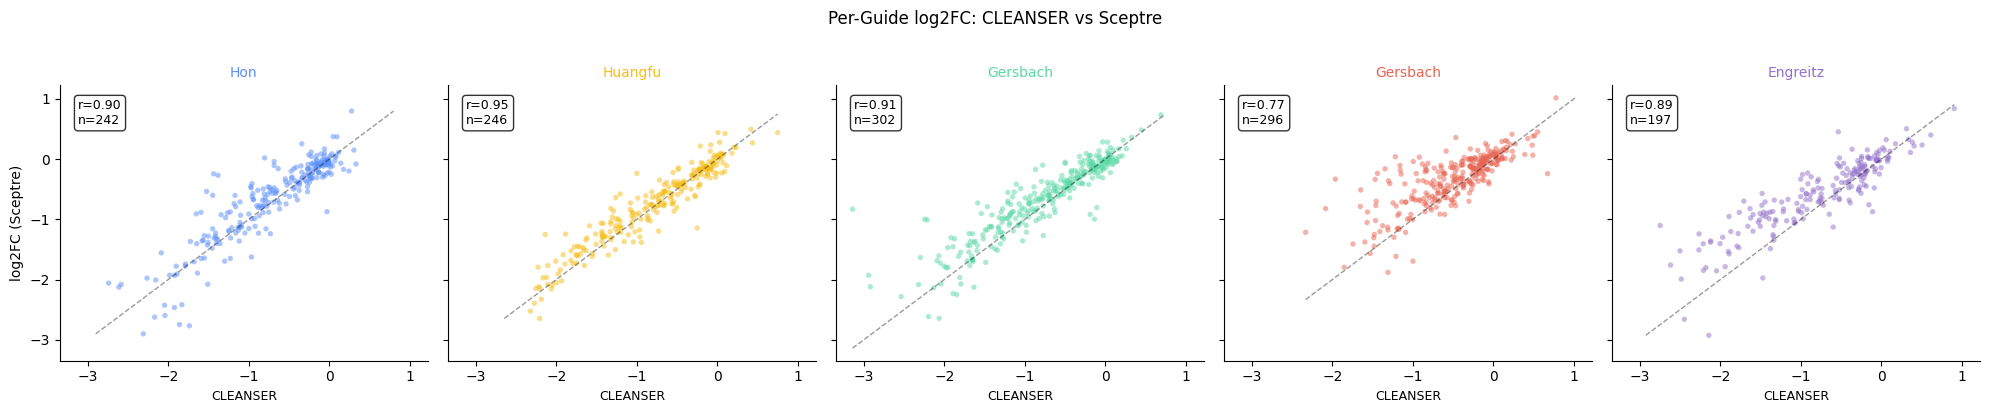

In [45]:
# Scatter: per-guide log2FC in CLEANSER vs Sceptre, per dataset
if len(run_labels) == 2:
    r1, r2 = run_labels
    
    fig, axes = plt.subplots(1, len(short_names), figsize=(4 * len(short_names), 4), sharey=True, sharex=True)

    for ax, sn in zip(axes, short_names):
        df1 = all_target_results[(all_target_results['run'] == r1) & (all_target_results['short_name'] == sn)]
        df2 = all_target_results[(all_target_results['run'] == r2) & (all_target_results['short_name'] == sn)]
        
        merged = df1[['guide_id', 'log2_fc']].merge(
            df2[['guide_id', 'log2_fc']], on='guide_id', suffixes=(f'_{r1}', f'_{r2}'),
            how='inner'
        ).dropna()
        
        if len(merged) > 0:
            from scipy.stats import pearsonr
            r, p = pearsonr(merged[f'log2_fc_{r1}'], merged[f'log2_fc_{r2}'])
            
            ax.scatter(merged[f'log2_fc_{r1}'], merged[f'log2_fc_{r2}'],
                      c=color_by_short[sn], s=15, alpha=0.5, edgecolor='none')
            
            lo = min(merged[f'log2_fc_{r1}'].min(), merged[f'log2_fc_{r2}'].min())
            hi = max(merged[f'log2_fc_{r1}'].max(), merged[f'log2_fc_{r2}'].max())
            ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, linewidth=1)
            ax.text(0.05, 0.95, f'r={r:.2f}\nn={len(merged)}', transform=ax.transAxes,
                   va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_title(sn.split()[0], fontsize=10, color=color_by_short[sn])
        ax.set_xlabel(run_display[r1], fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel(f'log2FC ({run_display[r2]})', fontsize=10)
    fig.suptitle('Per-Guide log2FC: CLEANSER vs Sceptre', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'target_log2fc_scatter.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [46]:
# Summary table: key metrics side by side
summary_cols = ['n_cells', 'guide_umi_median', 'guides_per_cell_mean',
                'frac_cells_with_guide', 'cells_per_guide_median']
target_cols = ['auroc', 'auprc', 'median_log2fc', 'frac_strong_knockdowns']

rows = []
for sn in short_names:
    row = {'Dataset': sn}
    for run in run_labels:
        label = run_display[run]
        g = all_guide[(all_guide['run'] == run) & (all_guide['short_name'] == sn)]
        t = all_target_metrics[(all_target_metrics['run'] == run) & (all_target_metrics['short_name'] == sn)]
        for col in summary_cols:
            row[f'{label}_{col}'] = g[col].values[0] if len(g) > 0 else np.nan
        for col in target_cols:
            row[f'{label}_{col}'] = t[col].values[0] if len(t) > 0 else np.nan
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Dataset')
summary_df.to_csv(OUTPUT_DIR / 'cross_run_summary.tsv', sep='\t')

# Display nicely
display(summary_df.round(3).T)

Dataset,Hon,Huangfu,Gersbach GEM-Xv3,Gersbach HTv2,Engreitz
CLEANSER_n_cells,73458.000,141251.000,67436.000,43376.000,467119.000
CLEANSER_guide_umi_median,829.000,99.000,451.000,72.000,4.000
CLEANSER_guides_per_cell_mean,1.573,0.942,1.084,0.620,0.234
CLEANSER_frac_cells_with_guide,0.914,0.651,0.696,0.348,0.183
CLEANSER_cells_per_guide_median,244.500,280.500,154.000,56.000,233.500
CLEANSER_auroc,0.778,0.801,0.799,0.742,0.801
CLEANSER_auprc,0.818,0.843,0.850,0.792,0.851
CLEANSER_median_log2fc,-0.627,-0.691,-0.669,-0.406,-0.571
CLEANSER_frac_strong_knockdowns,0.202,0.248,0.215,0.074,0.264
Sceptre_n_cells,57775.000,141251.000,50993.000,43376.000,434062.000


---
## 3. Combined Key Metrics (Single Row)

A single summary figure with the most important metrics across both gene and guide, side by side per run.

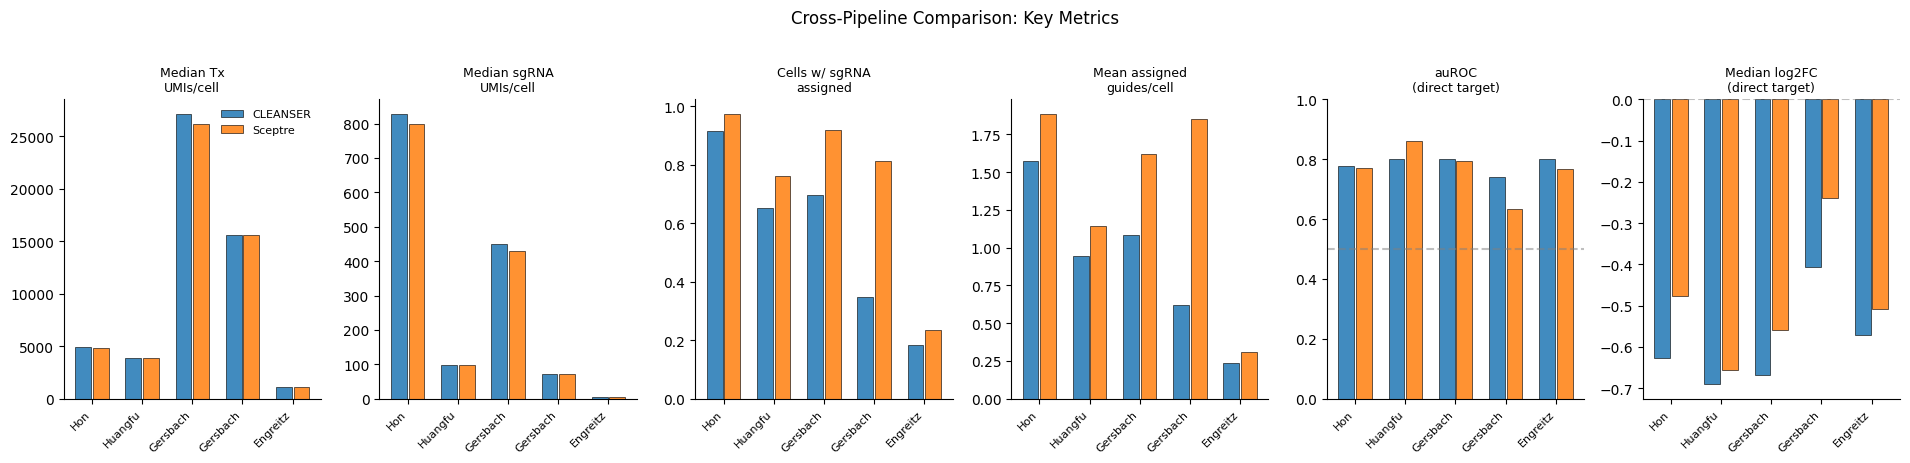

In [47]:
# Combined figure: gene + guide + target metrics in one row
combined_metrics = [
    ('gene',   'umi_median',             'Median Tx\nUMIs/cell'),
    ('guide',  'guide_umi_median',       'Median sgRNA\nUMIs/cell'),
    ('guide',  'frac_cells_with_guide',  'Cells w/ sgRNA\nassigned'),
    ('guide',  'guides_per_cell_mean',   'Mean assigned\nguides/cell'),
    ('target', 'auroc',                  'auROC\n(direct target)'),
    ('target', 'median_log2fc',          'Median log2FC\n(direct target)'),
]

source_map = {'gene': all_gene, 'guide': all_guide, 'target': all_target_metrics}

fig, axes = plt.subplots(1, len(combined_metrics), figsize=(3.2 * len(combined_metrics), 4.5))

for ax, (source, col, ylabel) in zip(axes, combined_metrics):
    df = source_map[source]
    for j, run in enumerate(run_labels):
        run_df = df[df['run'] == run]
        vals = []
        for sn in short_names:
            row = run_df[run_df['short_name'] == sn]
            vals.append(row[col].values[0] if len(row) > 0 else np.nan)
        offset = (j - 0.5 * (len(run_labels) - 1)) * width
        ax.bar(x + offset, vals, width * 0.9, label=run_display[run],
               color=run_colors[run], edgecolor='black', linewidth=0.5, alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels([sn.split()[0] for sn in short_names], fontsize=8, rotation=45, ha='right')
    ax.set_title(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add reference lines where appropriate
    if col == 'auroc':
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
    elif col == 'median_log2fc':
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

axes[0].legend(fontsize=8, frameon=False, loc='upper right')
fig.suptitle('Cross-Pipeline Comparison: Key Metrics', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_run_key_metrics.pdf', dpi=300, bbox_inches='tight')
plt.show()

# DONE!

---